In [1]:
#!/usr/bin/env python3
"""
evaluate_all_models.py
======================
Comprehensive evaluation of all Sinhala → SSL Sign Language Translation models.

Models evaluated:
  1. M2M100-418M with letters
  2. M2M100-418M (baseline)
  3. mT5-base
  4. NLLB200-distilled-600M
  5. Gemma3-270M
  6. Qwen3-0.6B-Base

Metrics computed:
  - BLEU-1, BLEU-2, BLEU-4         (sacrebleu)
  - ROUGE-1, ROUGE-2, ROUGE-L F1   (rouge_score)
  - WER  — Word Error Rate %        (jiwer,  lower = better)
  - SER  — Sentence Error Rate %    (1 − Exact Match,  lower = better)
  - METEOR                          (nltk,  higher = better)
  - TER  — Translation Edit Rate %  (sacrebleu,  lower = better)
  - Token Precision / Recall / F1   (multiset matching)
  - Exact Match %
  - Word Overlap %                  (unordered set recall)
  - SSL ID Overlap %
  - Position Accuracy %
  - Length Bias                      (mean predicted − mean reference)

Usage on Kaggle:
  1. Upload this file as a dataset or paste into a code cell.
  2. Update the MODEL_RESULTS dict below with the correct input paths.
  3. Run: !python evaluate_all_models.py
     or import and call evaluate_all_models() directly.
"""

# ── Auto-install dependencies ──────────────────────────────────────────────────
import subprocess, sys

def _ensure(pkg_import: str, pkg_install: str):
    try:
        __import__(pkg_import)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg_install, "-q"])

_ensure("sacrebleu",   "sacrebleu")
_ensure("rouge_score", "rouge_score")
_ensure("jiwer",       "jiwer")
_ensure("nltk",        "nltk")

# ── Standard imports ───────────────────────────────────────────────────────────
import os
from pathlib import Path
from typing  import List, Dict
from collections import Counter

import numpy  as np
import pandas as pd
import matplotlib.pyplot          as plt
import matplotlib.ticker          as mticker
import matplotlib.patches         as mpatches

import sacrebleu                  as sb
from rouge_score import rouge_scorer
import jiwer
import nltk

# Download METEOR wordnet data once (safe to call repeatedly)
for _r in ("wordnet", "omw-1.4"):
    try:
        nltk.data.find(f"corpora/{_r}")
    except LookupError:
        nltk.download(_r, quiet=True)


# ══════════════════════════════════════════════════════════════════════════════
# 1.  CONFIGURATION  ← UPDATE PATHS TO MATCH YOUR KAGGLE INPUT DATASETS
# ══════════════════════════════════════════════════════════════════════════════

MODEL_RESULTS: Dict[str, str] = {
    "M2M100-418M-fs": "/kaggle/input/models/nadeenudantha/sinhala-ssl-kaggle-m2m100-fs-final3/transformers/default/1/test_results.csv",
    "M2M100-418M": "/kaggle/input/models/nadeenudantha/sinhala-ssl-kaggle-m2m100/transformers/default/3/test_results.csv",
    "M2M100-1.2B": "/kaggle/input/models/nadeenudantha/sinhala-ssl-kaggle-m2m100-bigboi-final3/transformers/default/1/test_results.csv",
    "mT5": "/kaggle/input/models/nadeenudantha/sinhala-ssl-kaggle-mt5/transformers/default/2/test_results.csv",
    "NLLB200-600M": "/kaggle/input/models/nadeenudantha/sinhala-ssl-kaggle-nllb200-distil600m/transformers/default/2/test_results.csv",
    "Gemma3-270M": "/kaggle/input/models/nadeenudantha/sinhala-ssl-kaggle-gemma3-270m/transformers/default/2/test_results.csv",
    "Qwen3-0.6B": "/kaggle/input/models/nadeenudantha/sinhala-ssl-kaggle-qwen/transformers/default/3/test_results.csv",
    "XLM-RoBERTa": "/kaggle/input/datasets/nadeenudantha/xlm-test-results-final3/xlm-test_results.csv",
}

# If running locally, override with absolute paths:
#   MODEL_RESULTS["M2M100-418M"] = r"C:\path\to\m2m100_test_results.csv"

OUTPUT_DIR = "/kaggle/working"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 35.2 MB/s eta 0:00:00


  Sinhala → SSL  —  Model Evaluation Suite
  [EVAL] M2M100-418M                    … BLEU-4= 90.3  METEOR= 84.1  TER=   8.9  SER= 21.7  ROUGE-L= 44.0  Token F1= 87.8  WER=  8.9  Exact= 78.3
  [EVAL] M2M100-1.2B                    … BLEU-4= 89.3  METEOR= 84.3  TER=   9.9  SER= 21.5  ROUGE-L= 43.9  Token F1= 88.0  WER=  9.9  Exact= 78.5
  [EVAL] mT5                            … BLEU-4= 90.4  METEOR= 82.7  TER=   8.6  SER= 24.8  ROUGE-L= 43.8  Token F1= 86.2  WER=  8.7  Exact= 75.2
  [EVAL] NLLB200-600M                   … BLEU-4= 89.7  METEOR= 83.7  TER=   9.7  SER= 22.6  ROUGE-L= 44.1  Token F1= 87.7  WER=  9.8  Exact= 77.4
  [EVAL] Gemma3-270M                    … BLEU-4= 73.5  METEOR= 81.2  TER=  25.8  SER= 26.5  ROUGE-L= 43.9  Token F1= 84.2  WER= 25.9  Exact= 73.5
  [EVAL] Qwen3-0.6B                     … BLEU-4= 91.0  METEOR= 81.7  TER=   9.1  SER= 25.2  ROUGE-L= 44.0  Token F1= 85.4  WER=  9.1  Exact= 74.8
  [EVAL] XLM-RoBERTa                    … BLEU-4= 83.6  METEOR= 31.7  TER= 

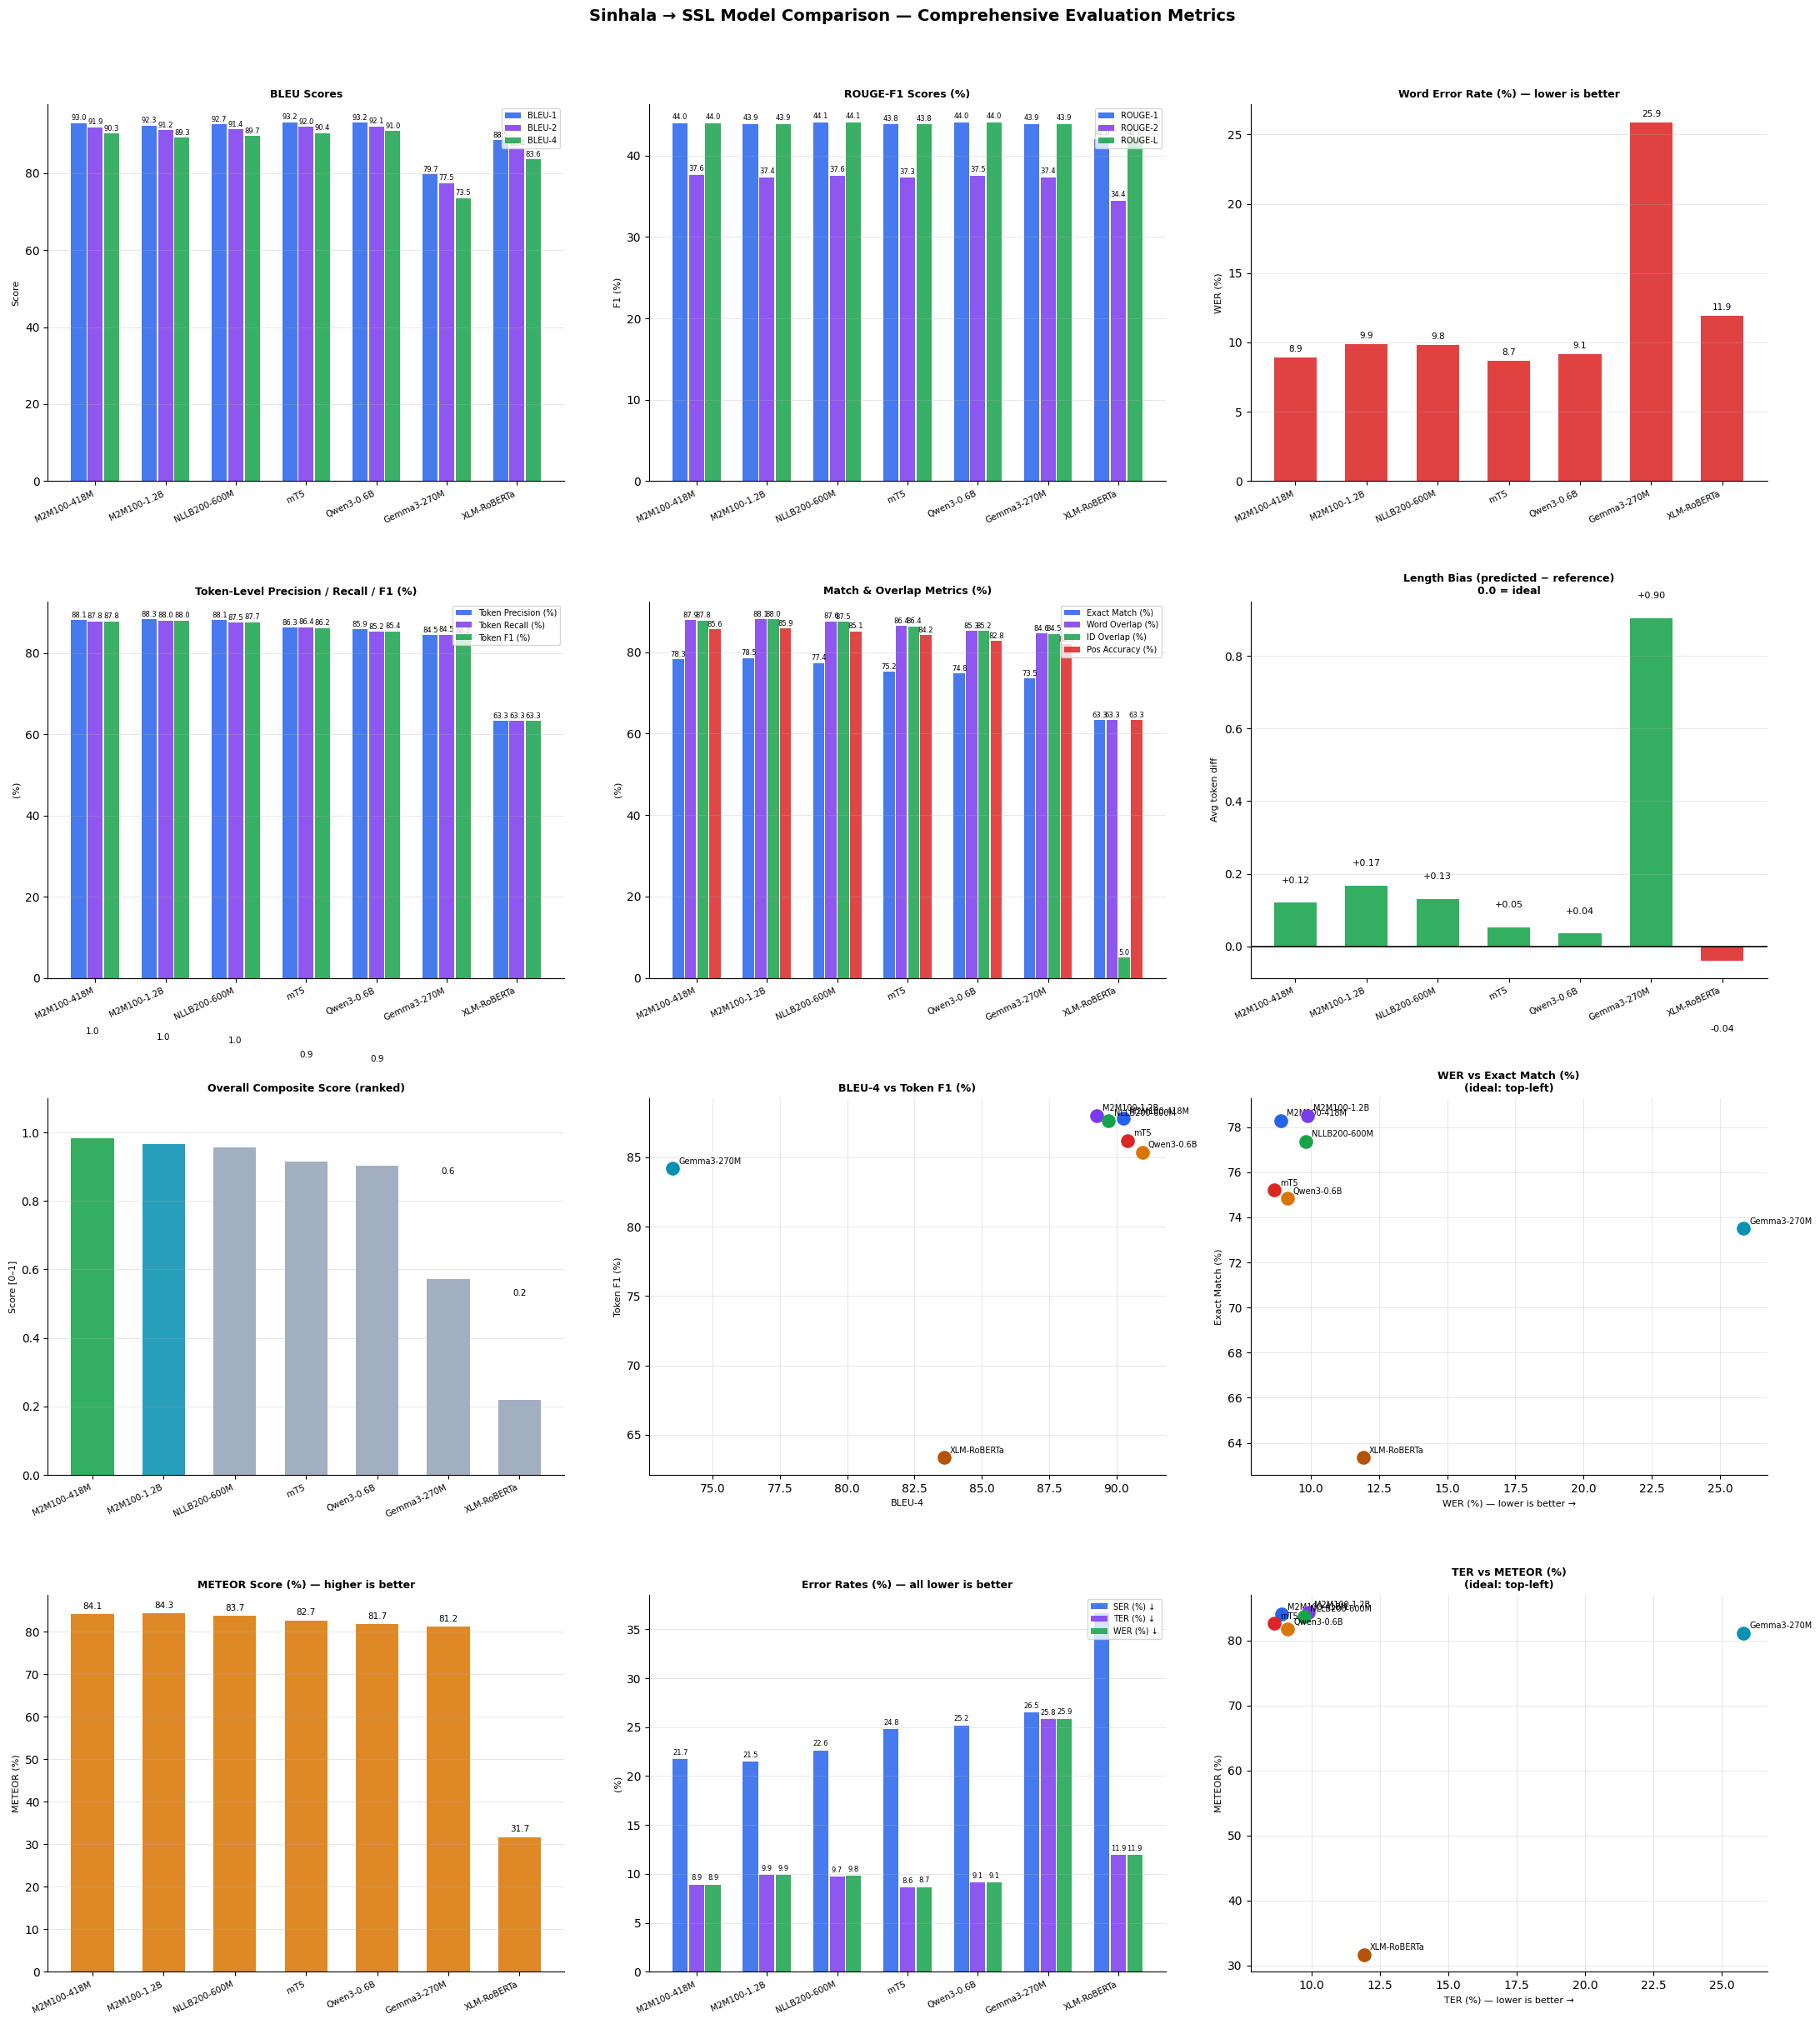

  ✓ Plot saved     → /kaggle/working/model_comparison_metrics.png

Done.


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.  TOKEN PARSING HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def _parse_pipe(cell) -> List[str]:
    """Split a pipe-separated token cell into a clean list of strings."""
    if pd.isna(cell) or str(cell).strip() == "":
        return []
    return [t.strip() for t in str(cell).split("|") if t.strip()]


# ══════════════════════════════════════════════════════════════════════════════
# 3.  METRIC FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

# ── 3a. BLEU ──────────────────────────────────────────────────────────────────

def compute_bleu(refs: List[List[str]], hyps: List[List[str]]) -> Dict[str, float]:
    """
    Corpus-level BLEU-1, BLEU-2, BLEU-4 using sacrebleu 2.6.0.
    (The BLEU class / corpus_bleu in 2.6.0 does not support max_ngram_order,
     so we compute full BLEU-4 once and derive the lower-order scores from precisions + BP.)
    """
    ref_strs = [" ".join(r) for r in refs]
    hyp_strs = [" ".join(h) for h in hyps]

    # One single call – sacrebleu 2.6.0 always computes up to 4-grams
    score = sb.corpus_bleu(hyp_strs, [ref_strs], smooth_method="exp")

    precisions = score.precisions   # list of 4 values: p1, p2, p3, p4 (already in percent)
    bp = score.bp

    out = {}
    for n in [1, 2, 4]:
        # BLEU-n = BP × (p1 × p2 × ... × pn)^{1/n}
        prod = 1.0
        for i in range(n):
            prod *= precisions[i]
        bleu_n = bp * (prod ** (1.0 / n))
        out[f"BLEU-{n}"] = round(bleu_n, 2)

    return out


# ── 3b. ROUGE ─────────────────────────────────────────────────────────────────

def compute_rouge(refs: List[List[str]], hyps: List[List[str]]) -> Dict[str, float]:
    """
    Sentence-averaged ROUGE-1 / ROUGE-2 / ROUGE-L F1 (%).
    Words are joined with spaces; rouge_score tokenises on whitespace.
    """
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"],
                                      use_stemmer=False)
    buckets: Dict[str, List[float]] = {"rouge1": [], "rouge2": [], "rougeL": []}

    for ref, hyp in zip(refs, hyps):
        ref_str = " ".join(ref) if ref else "__empty__"
        hyp_str = " ".join(hyp) if hyp else "__empty__"
        s = scorer.score(ref_str, hyp_str)
        for k in buckets:
            buckets[k].append(s[k].fmeasure)

    return {
        "ROUGE-1": round(np.mean(buckets["rouge1"]) * 100, 2),
        "ROUGE-2": round(np.mean(buckets["rouge2"]) * 100, 2),
        "ROUGE-L": round(np.mean(buckets["rougeL"]) * 100, 2),
    }


# ── 3c. WER ───────────────────────────────────────────────────────────────────

def compute_wer(refs: List[List[str]], hyps: List[List[str]]) -> float:
    """
    Corpus Word Error Rate (%).
    Each token sequence is treated as a sentence of 'words'.
    """
    ref_strs = [" ".join(r) if r else "__empty__" for r in refs]
    hyp_strs = [" ".join(h) if h else "__empty__" for h in hyps]
    try:
        rate = jiwer.wer(ref_strs, hyp_strs)
    except Exception:
        rate = float("nan")
    return round(rate * 100, 2)


# ── 3d. Token Precision / Recall / F1 ────────────────────────────────────────

def compute_token_prf(refs: List[List[str]], hyps: List[List[str]]) -> Dict[str, float]:
    """
    Multiset (bag-of-words) Precision, Recall, and F1 — micro-averaged across sentences.
    Correctly handles repeated tokens.
    """
    precs, recs, f1s = [], [], []
    for ref, hyp in zip(refs, hyps):
        ref_c = Counter(ref)
        hyp_c = Counter(hyp)
        tp = sum((hyp_c & ref_c).values())          # true positives (multiset intersection)
        prec = tp / max(sum(hyp_c.values()), 1)
        rec  = tp / max(sum(ref_c.values()), 1)
        f1   = (2 * prec * rec) / max(prec + rec, 1e-9)
        precs.append(prec); recs.append(rec); f1s.append(f1)

    return {
        "Token Precision (%)": round(np.mean(precs) * 100, 2),
        "Token Recall (%)":    round(np.mean(recs)  * 100, 2),
        "Token F1 (%)":        round(np.mean(f1s)   * 100, 2),
    }


# ── 3e. Exact Match ───────────────────────────────────────────────────────────

def compute_exact_match(refs: List[List[str]], hyps: List[List[str]]) -> float:
    return round(np.mean([r == h for r, h in zip(refs, hyps)]) * 100, 2)


# ── 3f. Word Overlap (unordered recall) ───────────────────────────────────────

def compute_word_overlap(refs: List[List[str]], hyps: List[List[str]]) -> float:
    scores = [len(set(r) & set(h)) / max(len(set(r)), 1) for r, h in zip(refs, hyps)]
    return round(np.mean(scores) * 100, 2)


# ── 3g. SSL ID Overlap ────────────────────────────────────────────────────────

def compute_id_overlap(ref_ids: List[List[str]], hyp_ids: List[List[str]]) -> float:
    scores = [len(set(r) & set(h)) / max(len(set(r)), 1) for r, h in zip(ref_ids, hyp_ids)]
    return round(np.mean(scores) * 100, 2)


# ── 3h. Position Accuracy ─────────────────────────────────────────────────────

def compute_position_accuracy(refs: List[List[str]], hyps: List[List[str]]) -> float:
    scores = []
    for ref, hyp in zip(refs, hyps):
        ml      = min(len(ref), len(hyp))
        correct = sum(1 for i in range(ml) if ref[i] == hyp[i])
        scores.append(correct / max(len(ref), 1))
    return round(np.mean(scores) * 100, 2)


# ── 3i. Length Bias ───────────────────────────────────────────────────────────

def compute_length_bias(refs: List[List[str]], hyps: List[List[str]]) -> float:
    """Mean (predicted_length − reference_length). Zero = perfect."""
    return round(float(np.mean([len(h) - len(r) for r, h in zip(refs, hyps)])), 3)


# ── 3j. SER — Sentence Error Rate ────────────────────────────────────────────

def compute_ser(refs: List[List[str]], hyps: List[List[str]]) -> float:
    """
    Sentence Error Rate (%) — percentage of sentences where the prediction
    differs from the reference by at least one token.
    SER = 100 − Exact_Match_%.   Lower is better.
    """
    errors = sum(1 for r, h in zip(refs, hyps) if r != h)
    return round(errors / max(len(refs), 1) * 100, 2)


# ── 3k. METEOR ────────────────────────────────────────────────────────────────

def compute_meteor(refs: List[List[str]], hyps: List[List[str]]) -> float:
    """
    Sentence-averaged METEOR score (%) using nltk.
    No stemming applied — each SSL gloss word is treated as-is.
    Higher is better.
    """
    from nltk.translate.meteor_score import meteor_score as _meteor
    scores = []
    for ref, hyp in zip(refs, hyps):
        ref_tok = ref if ref else ["__empty__"]
        hyp_tok = hyp if hyp else ["__empty__"]
        try:
            s = _meteor([ref_tok], hyp_tok)
        except Exception:
            s = 0.0
        scores.append(s)
    return round(float(np.mean(scores)) * 100, 2)


# ── 3l. TER — Translation Edit Rate ──────────────────────────────────────────

def compute_ter(refs: List[List[str]], hyps: List[List[str]]) -> float:
    """
    Corpus-level TER (%) via sacrebleu.  Lower is better.
    Counts the number of edits (insertions, deletions, substitutions, shifts)
    needed to convert the hypothesis into the reference, normalised by
    the number of reference tokens.
    """
    ref_strs = [" ".join(r) if r else "__empty__" for r in refs]
    hyp_strs = [" ".join(h) if h else "__empty__" for h in hyps]
    try:
        result = sb.corpus_ter(hyp_strs, [ref_strs])
        return round(result.score, 2)
    except Exception:
        return float("nan")


# ══════════════════════════════════════════════════════════════════════════════
# 4.  EVALUATE ONE MODEL
# ══════════════════════════════════════════════════════════════════════════════

def evaluate_model_csv(csv_path: str, display_name: str) -> Dict:
    """Load test_results.csv and return a dict of all metrics for one model."""
    df = pd.read_csv(csv_path)

    if "correct_words" not in df:
        df["correct_words"] = df["reference"]
        df["predicted_words"] = df["prediction"]
        df["correct_ids"] = df["ref_ids"]
        df["predicted_ids"] = df["pred_ids"]

    refs    = [_parse_pipe(x) for x in df["correct_words"]]
    hyps    = [_parse_pipe(x) for x in df["predicted_words"]]
    ref_ids = [_parse_pipe(x) for x in df["correct_ids"]]
    hyp_ids = [_parse_pipe(x) for x in df["predicted_ids"]]

    # Strip FS tokens for fair comparison (M2M100-fs model only)
    if display_name == "M2M100-418M-fs":
        _FS_W = {"<FS>", "-"}
        _FS_I = {"4", "1700"}
        refs    = [[w for w in r if w not in _FS_W] for r in refs]
        hyps    = [[w for w in h if w not in _FS_W] for h in hyps]
        ref_ids = [[i for i in r if i not in _FS_I] for r in ref_ids]
        hyp_ids = [[i for i in h if i not in _FS_I] for h in hyp_ids]
    
    m: Dict = {"Model": display_name, "N (test)": len(df)}

    m.update(compute_bleu(refs, hyps))
    m.update(compute_rouge(refs, hyps))
    m["WER (%) ↓"]         = compute_wer(refs, hyps)
    m.update(compute_token_prf(refs, hyps))
    m["Exact Match (%)"]   = compute_exact_match(refs, hyps)
    m["SER (%) ↓"]         = compute_ser(refs, hyps)
    m["METEOR (%)"]        = compute_meteor(refs, hyps)
    m["TER (%) ↓"]         = compute_ter(refs, hyps)
    m["Word Overlap (%)"]  = compute_word_overlap(refs, hyps)
    m["ID Overlap (%)"]    = compute_id_overlap(ref_ids, hyp_ids)
    m["Pos Accuracy (%)"]  = compute_position_accuracy(refs, hyps)
    m["Length Bias"]       = compute_length_bias(refs, hyps)

    return m


# ══════════════════════════════════════════════════════════════════════════════
# 5.  MAIN: EVALUATE ALL MODELS
# ══════════════════════════════════════════════════════════════════════════════

def evaluate_all_models(
    model_results: Dict[str, str] = None,
    output_dir:    str             = None,
) -> pd.DataFrame:
    """
    Run evaluation across all models and return a ranked DataFrame.

    Parameters
    ----------
    model_results : dict  {display_name: csv_path}   (defaults to MODULE-LEVEL constant)
    output_dir    : str   where to save CSVs and plots (defaults to MODULE-LEVEL constant)
    """
    if model_results is None:
        model_results = MODEL_RESULTS
    if output_dir is None:
        output_dir = OUTPUT_DIR

    os.makedirs(output_dir, exist_ok=True)

    # ── 5a. Collect metrics ───────────────────────────────────────────────────
    rows = []
    for name, path in model_results.items():
        display = name.replace("\n", " ")
        if not Path(path).exists():
            raise RuntimeError(f"  [SKIP] {display:30s} — not found: {path}")
            #print(f"  [SKIP] {display:30s} — not found: {path}")
            #continue
        print(f"  [EVAL] {display:30s} … ", end="", flush=True)
        row = evaluate_model_csv(path, name)
        rows.append(row)
        print(f"BLEU-4={row['BLEU-4']:5.1f}  "
              f"METEOR={row['METEOR (%)']:5.1f}  "
              f"TER={row['TER (%) ↓']:6.1f}  "
              f"SER={row['SER (%) ↓']:5.1f}  "
              f"ROUGE-L={row['ROUGE-L']:5.1f}  "
              f"Token F1={row['Token F1 (%)']:5.1f}  "
              f"WER={row['WER (%) ↓']:5.1f}  "
              f"Exact={row['Exact Match (%)']:5.1f}")

    if not rows:
        raise RuntimeError(
            "No CSV files were found. Please update MODEL_RESULTS paths at the top "
            "of evaluate_all_models.py to match your Kaggle input dataset paths.")

    df = pd.DataFrame(rows).set_index("Model")

    # ── 5b. Composite ranking ─────────────────────────────────────────────────
    # Normalise each metric to [0, 1]; WER is inverted (lower → higher score).
    higher_is_better = ["BLEU-4", "ROUGE-L", "METEOR (%)", "Token F1 (%)",
                        "Exact Match (%)", "Word Overlap (%)", "Pos Accuracy (%)"]
    lower_is_better  = ["WER (%) ↓", "SER (%) ↓", "TER (%) ↓"]

    df_n = df[higher_is_better + lower_is_better].copy().astype(float)
    for col in higher_is_better:
        mn, mx = df_n[col].min(), df_n[col].max()
        df_n[col] = (df_n[col] - mn) / (mx - mn + 1e-9)
    for col in lower_is_better:
        mn, mx = df_n[col].min(), df_n[col].max()
        df_n[col] = 1.0 - (df_n[col] - mn) / (mx - mn + 1e-9)

    df["Composite Score"] = df_n.mean(axis=1).round(4)
    df = df.sort_values("Composite Score", ascending=False)

    # ── 5c. Save CSVs ────────────────────────────────────────────────────────
    df.to_csv(f"{output_dir}/all_model_evaluation.csv")
    print(f"\n  ✓ Full metrics  → {output_dir}/all_model_evaluation.csv")

    # ── 5d. Print summary table ───────────────────────────────────────────────
    DISPLAY = [
        "N (test)",
        "BLEU-1", "BLEU-2", "BLEU-4",
        "ROUGE-1", "ROUGE-2", "ROUGE-L",
        "METEOR (%)",
        "WER (%) ↓", "SER (%) ↓", "TER (%) ↓",
        "Token Precision (%)", "Token Recall (%)", "Token F1 (%)",
        "Exact Match (%)", "Word Overlap (%)", "ID Overlap (%)",
        "Pos Accuracy (%)", "Length Bias", "Composite Score",
    ]
    available = [c for c in DISPLAY if c in df.columns]

    print("\n" + "═" * 145)
    print("  COMPREHENSIVE EVALUATION SUMMARY — Sinhala → SSL Translation")
    print("═" * 145)
    print(df[available].to_string())
    print("═" * 145)
    print("  ↑ Higher is better: BLEU, ROUGE, METEOR, Token F1, Exact Match, "
          "Word Overlap, ID Overlap, Pos Accuracy, Composite Score")
    print("  ↓ Lower  is better: WER, SER, TER.   "
          "Length Bias: 0.0 = perfect length prediction  "
          "(positive = over-generates, negative = under-generates)")
    print("═" * 145)

    # ── 5e. Plots ─────────────────────────────────────────────────────────────
    _plot_comparison(df, output_dir)

    return df


# ══════════════════════════════════════════════════════════════════════════════
# 6.  PLOTTING
# ══════════════════════════════════════════════════════════════════════════════

_PALETTE = ["#2563eb", "#7c3aed", "#16a34a", "#dc2626", "#d97706", "#0891b2",
            "#b45309", "#be185d", "#0f766e", "#1d4ed8"]

def _barplot(ax, models: List[str], values: List[float],
             title: str, ylabel: str,
             colors=None, annotate: bool = True):
    if colors is None:
        colors = _PALETTE[:len(models)]
    bars = ax.bar(range(len(models)), values, color=colors, alpha=0.87, width=0.6)
    if annotate:
        for bar, v in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(max(values, default=1) * 0.01, 0.3),
                    f"{v:.1f}", ha="center", va="bottom", fontsize=7.5)
    ax.set_title(title, fontweight="bold", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace("\n", " ") for m in models],
                       rotation=25, ha="right", fontsize=7.5)
    ax.grid(axis="y", alpha=0.3, linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)


def _grouped_barplot(ax, models: List[str], col_val_map: Dict[str, List[float]],
                     title: str, ylabel: str):
    n_grps  = len(models)
    n_bars  = len(col_val_map)
    width   = 0.7 / n_bars
    x       = np.arange(n_grps)
    for i, (label, vals) in enumerate(col_val_map.items()):
        offset = (i - n_bars / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width * 0.92,
                      label=label, color=_PALETTE[i % len(_PALETTE)], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=6)
    ax.set_title(title, fontweight="bold", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("\n", " ") for m in models],
                       rotation=25, ha="right", fontsize=7.5)
    ax.legend(fontsize=7, loc="upper right", framealpha=0.8)
    ax.grid(axis="y", alpha=0.3, linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)


def _plot_comparison(df: pd.DataFrame, output_dir: str):
    models  = df.index.tolist()
    n       = len(models)
    colors  = _PALETTE[:n]

    fig, axes = plt.subplots(4, 3, figsize=(22, 24))
    fig.suptitle(
        "Sinhala → SSL Model Comparison — Comprehensive Evaluation Metrics",
        fontsize=14, fontweight="bold", y=1.01)

    # ── (0,0) BLEU ────────────────────────────────────────────────────
    _grouped_barplot(
        axes[0, 0], models,
        {k: [df.loc[m, k] for m in models]
         for k in ["BLEU-1", "BLEU-2", "BLEU-4"] if k in df.columns},
        "BLEU Scores", "Score")

    # ── (0,1) ROUGE ───────────────────────────────────────────────────
    _grouped_barplot(
        axes[0, 1], models,
        {k: [df.loc[m, k] for m in models]
         for k in ["ROUGE-1", "ROUGE-2", "ROUGE-L"] if k in df.columns},
        "ROUGE-F1 Scores (%)", "F1 (%)")

    # ── (0,2) WER ─────────────────────────────────────────────────────
    col = "WER (%) ↓"
    vals = [df.loc[m, col] for m in models] if col in df.columns else [0]*n
    _barplot(axes[0, 2], models, vals,
             "Word Error Rate (%) — lower is better", "WER (%)",
             colors=["#dc2626"] * n)

    # ── (1,0) Token P/R/F1 ────────────────────────────────────────────
    _grouped_barplot(
        axes[1, 0], models,
        {k: [df.loc[m, k] for m in models]
         for k in ["Token Precision (%)", "Token Recall (%)", "Token F1 (%)"]
         if k in df.columns},
        "Token-Level Precision / Recall / F1 (%)", "(%)")

    # ── (1,1) Match & Overlap ─────────────────────────────────────────
    _grouped_barplot(
        axes[1, 1], models,
        {k: [df.loc[m, k] for m in models]
         for k in ["Exact Match (%)", "Word Overlap (%)",
                   "ID Overlap (%)", "Pos Accuracy (%)"]
         if k in df.columns},
        "Match & Overlap Metrics (%)", "(%)")

    # ── (1,2) Length Bias ─────────────────────────────────────────────
    col = "Length Bias"
    lb_vals = [df.loc[m, col] for m in models] if col in df.columns else [0]*n
    lb_colors = [_PALETTE[3] if v < 0 else _PALETTE[2] for v in lb_vals]
    ax = axes[1, 2]
    bars = ax.bar(range(n), lb_vals, color=lb_colors, alpha=0.87, width=0.6)
    for bar, v in zip(bars, lb_vals):
        offset = max(abs(v) * 0.03, 0.05)
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + (offset if v >= 0 else -offset * 4),
                f"{v:+.2f}", ha="center", va="bottom", fontsize=8)
    ax.axhline(0, color="black", linewidth=1.2)
    ax.set_title("Length Bias (predicted − reference)\n0.0 = ideal", fontweight="bold", fontsize=9)
    ax.set_ylabel("Avg token diff", fontsize=8)
    ax.set_xticks(range(n))
    ax.set_xticklabels([m.replace("\n", " ") for m in models],
                       rotation=25, ha="right", fontsize=7.5)
    ax.grid(axis="y", alpha=0.3, linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)

    # ── (2,0) Composite Score (radar-style bar) ────────────────────────
    col = "Composite Score"
    cs_vals = [df.loc[m, col] for m in models] if col in df.columns else [0]*n
    sorted_idx = sorted(range(n), key=lambda i: cs_vals[i], reverse=True)
    s_models = [models[i] for i in sorted_idx]
    s_vals   = [cs_vals[i] for i in sorted_idx]
    rank_colors = [_PALETTE[2] if i == 0 else
                   _PALETTE[5] if i == 1 else
                   "#94a3b8" for i in range(n)]
    _barplot(axes[2, 0], s_models, s_vals,
             "Overall Composite Score (ranked)", "Score [0–1]",
             colors=rank_colors)
    axes[2, 0].set_ylim(0, 1.1)

    # ── (2,1) BLEU-4 vs Token F1 scatter ─────────────────────────────
    ax = axes[2, 1]
    bleu4_c = "BLEU-4"
    tf1_c   = "Token F1 (%)"
    if bleu4_c in df.columns and tf1_c in df.columns:
        for i, m in enumerate(models):
            ax.scatter(df.loc[m, bleu4_c], df.loc[m, tf1_c],
                       color=_PALETTE[i % len(_PALETTE)], s=120, zorder=3)
            ax.annotate(m.replace("\n", " "),
                        (df.loc[m, bleu4_c], df.loc[m, tf1_c]),
                        textcoords="offset points", xytext=(5, 4), fontsize=7)
        ax.set_xlabel("BLEU-4", fontsize=8)
        ax.set_ylabel("Token F1 (%)", fontsize=8)
        ax.set_title("BLEU-4 vs Token F1 (%)", fontweight="bold", fontsize=9)
        ax.grid(alpha=0.3, linewidth=0.7)
        ax.spines[["top", "right"]].set_visible(False)

    # ── (2,2) WER vs Exact Match scatter ─────────────────────────────
    ax = axes[2, 2]
    wer_c = "WER (%) ↓"
    em_c  = "Exact Match (%)"
    if wer_c in df.columns and em_c in df.columns:
        for i, m in enumerate(models):
            ax.scatter(df.loc[m, wer_c], df.loc[m, em_c],
                       color=_PALETTE[i % len(_PALETTE)], s=120, zorder=3)
            ax.annotate(m.replace("\n", " "),
                        (df.loc[m, wer_c], df.loc[m, em_c]),
                        textcoords="offset points", xytext=(5, 4), fontsize=7)
        ax.set_xlabel("WER (%) — lower is better →", fontsize=8)
        ax.set_ylabel("Exact Match (%)", fontsize=8)
        ax.set_title("WER vs Exact Match (%)\n(ideal: top-left)", fontweight="bold", fontsize=9)
        ax.grid(alpha=0.3, linewidth=0.7)
        ax.spines[["top", "right"]].set_visible(False)

    # ── (3,0) METEOR ─────────────────────────────────────────────────
    col = "METEOR (%)"
    meteor_vals = [df.loc[m, col] for m in models] if col in df.columns else [0]*n
    _barplot(axes[3, 0], models, meteor_vals,
             "METEOR Score (%) — higher is better", "METEOR (%)",
             colors=[_PALETTE[4]] * n)

    # ── (3,1) SER / TER / WER grouped ────────────────────────────────
    _grouped_barplot(
        axes[3, 1], models,
        {k: [df.loc[m, k] for m in models]
         for k in ["SER (%) ↓", "TER (%) ↓", "WER (%) ↓"] if k in df.columns},
        "Error Rates (%) — all lower is better", "(%)")

    # ── (3,2) METEOR vs TER scatter ───────────────────────────────────
    ax = axes[3, 2]
    met_c = "METEOR (%)"
    ter_c = "TER (%) ↓"
    if met_c in df.columns and ter_c in df.columns:
        for i, m in enumerate(models):
            ax.scatter(df.loc[m, ter_c], df.loc[m, met_c],
                       color=_PALETTE[i % len(_PALETTE)], s=120, zorder=3)
            ax.annotate(m.replace("\n", " "),
                        (df.loc[m, ter_c], df.loc[m, met_c]),
                        textcoords="offset points", xytext=(5, 4), fontsize=7)
        ax.set_xlabel("TER (%) — lower is better →", fontsize=8)
        ax.set_ylabel("METEOR (%)", fontsize=8)
        ax.set_title("TER vs METEOR (%)\n(ideal: top-left)", fontweight="bold", fontsize=9)
        ax.grid(alpha=0.3, linewidth=0.7)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.99])
    out_path = f"{output_dir}/model_comparison_metrics.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ Plot saved     → {out_path}")


# ══════════════════════════════════════════════════════════════════════════════
# 7.  ENTRY POINT
# ══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    print("=" * 60)
    print("  Sinhala → SSL  —  Model Evaluation Suite")
    print("=" * 60)
    df_ranked = evaluate_all_models(model_results={k: v for k, v in MODEL_RESULTS.items() if k != "M2M100-418M-fs"})
    print("\nDone.")


  [FS Comparison]  Pure-gloss subset: 1503/1653 sentences
  [EVAL] M2M100-fs (no FS lines)                        … BLEU-4= 81.0  WER= 17.1  Exact= 77.5
  [EVAL] M2M100-418M (no FS lines)                      … BLEU-4= 89.7  WER=  9.7  Exact= 77.5
  [EVAL] M2M100-fs (full)                               … BLEU-4= 83.6  WER= 14.8  Exact= 78.3
  [EVAL] M2M100-418M (full)                             … BLEU-4= 90.3  WER=  8.9  Exact= 78.3

══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  FS MODEL COMPARISON  (M2M100-fs vs M2M100-418M)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
                           N (test)  BLEU-4  ROUGE-L  METEOR (%)  WER (%) ↓  TER (%) ↓  Token F1 (%)  Exact Match (%)  Word Overlap (%)  Pos Accuracy (%)  Length Bias  Alt Composite
Model                                                             

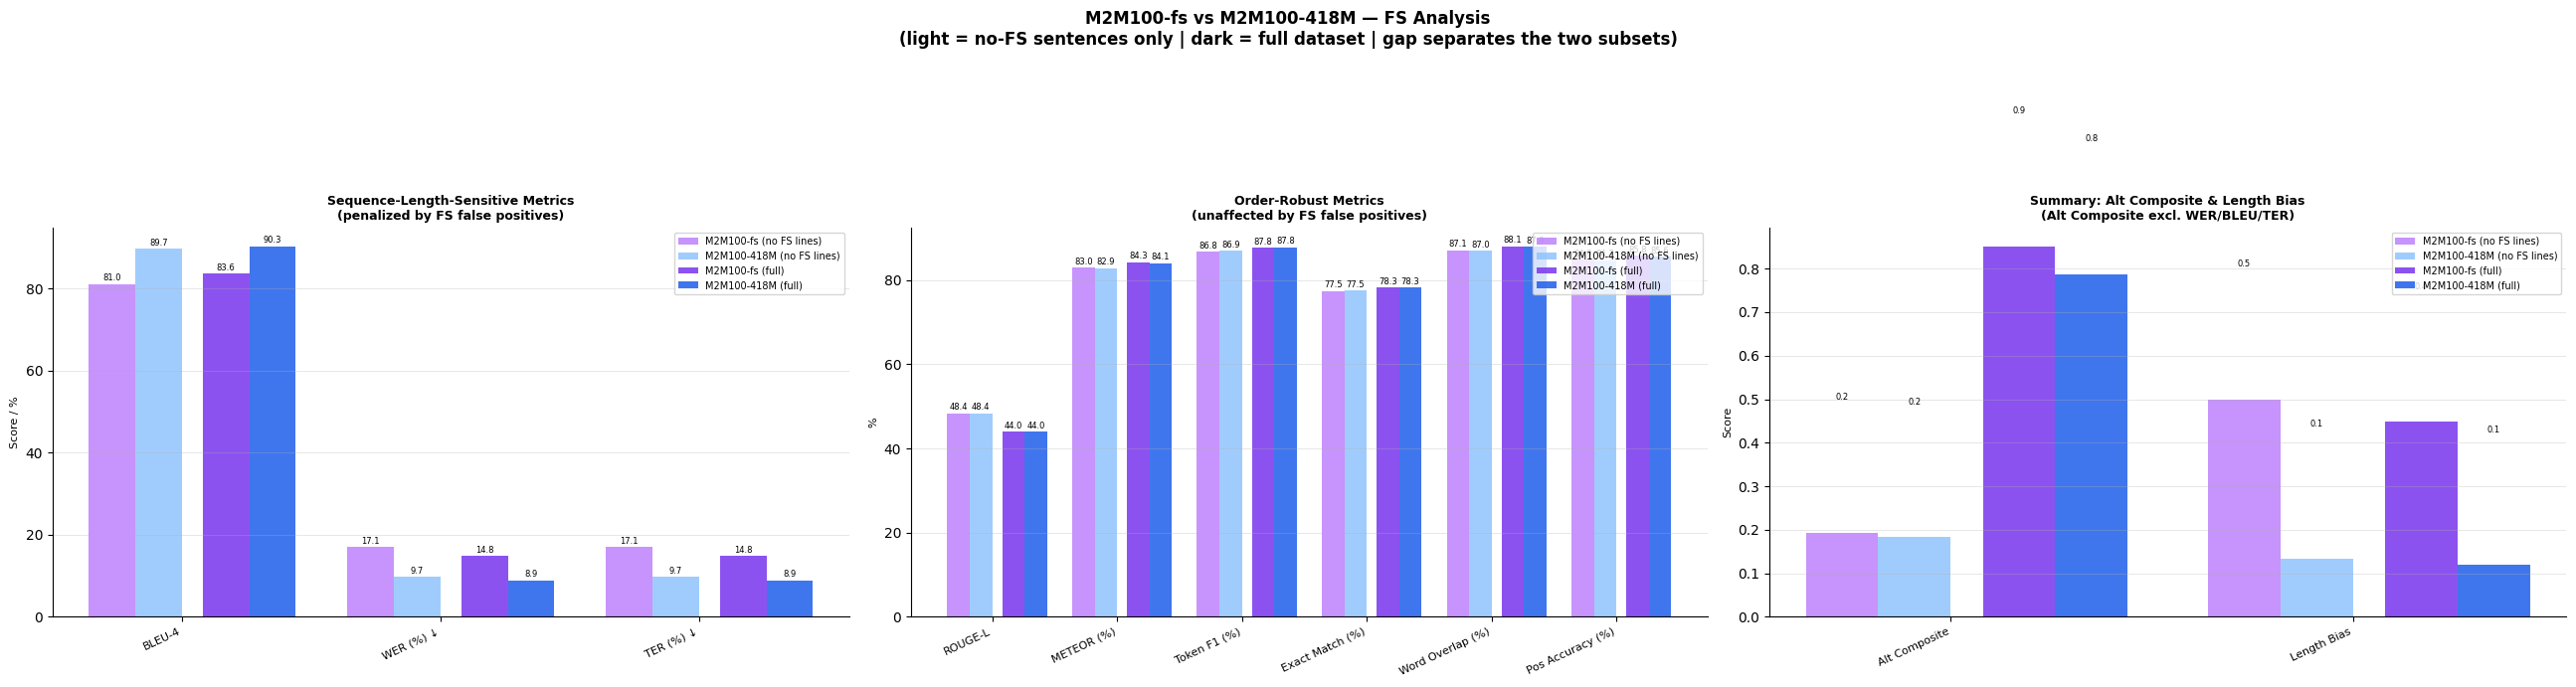

  ✓ FS comparison plot → /kaggle/working/fs_comparison_metrics.png


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# FS MODEL DETAILED COMPARISON
# ══════════════════════════════════════════════════════════════════════════════

def _evaluate_df(df, display_name):
    """Evaluate metrics directly from a pre-filtered DataFrame."""
    df = df.copy()
    if "correct_words" not in df.columns:
        df["correct_words"]   = df["reference"];  df["predicted_words"] = df["prediction"]
        df["correct_ids"]     = df["ref_ids"];    df["predicted_ids"]   = df["pred_ids"]
    refs    = [_parse_pipe(x) for x in df["correct_words"]]
    hyps    = [_parse_pipe(x) for x in df["predicted_words"]]
    ref_ids = [_parse_pipe(x) for x in df["correct_ids"]]
    hyp_ids = [_parse_pipe(x) for x in df["predicted_ids"]]
    m = {"Model": display_name, "N (test)": len(df)}
    m.update(compute_bleu(refs, hyps));  m.update(compute_rouge(refs, hyps))
    m["WER (%) ↓"]        = compute_wer(refs, hyps)
    m.update(compute_token_prf(refs, hyps))
    m["Exact Match (%)"]  = compute_exact_match(refs, hyps)
    m["SER (%) ↓"]        = compute_ser(refs, hyps)
    m["METEOR (%)"]       = compute_meteor(refs, hyps)
    m["TER (%) ↓"]        = compute_ter(refs, hyps)
    m["Word Overlap (%)"] = compute_word_overlap(refs, hyps)
    m["ID Overlap (%)"]   = compute_id_overlap(ref_ids, hyp_ids)
    m["Pos Accuracy (%)"] = compute_position_accuracy(refs, hyps)
    m["Length Bias"]      = compute_length_bias(refs, hyps)
    return m


def evaluate_fs_comparison(fs_path, nonfs_path, output_dir=OUTPUT_DIR):
    _FS_W = {"<FS>", "-"};  _FS_I = {"4", "1700"}
    os.makedirs(output_dir, exist_ok=True)

    df_fs    = pd.read_csv(fs_path)
    df_nonfs = pd.read_csv(nonfs_path)
    if "correct_words" not in df_nonfs.columns:
        df_nonfs = df_nonfs.rename(columns={
            "reference": "correct_words", "prediction": "predicted_words",
            "ref_ids":   "correct_ids",   "pred_ids":  "predicted_ids"})

    # Idea 1: filter to non-FS sentences
    fs_noFS = df_fs[~df_fs["correct_words"].str.contains("<FS>", na=False)].copy()
    for col in ("correct_words", "predicted_words"):
        fs_noFS[col] = fs_noFS[col].apply(
            lambda x: " | ".join(w for w in _parse_pipe(x) if w not in _FS_W))
    for col in ("correct_ids", "predicted_ids"):
        fs_noFS[col] = fs_noFS[col].apply(
            lambda x: " | ".join(i for i in _parse_pipe(x) if i not in _FS_I))
    nonfs_noFS = (df_nonfs[df_nonfs["source"].isin(set(fs_noFS["source"]))]
                  if "source" in df_nonfs.columns else df_nonfs).copy()

    rows = []
    print(f"\n  [FS Comparison]  Pure-gloss subset: {len(fs_noFS)}/{len(df_fs)} sentences")
    for label, df in [("M2M100-fs (no FS lines)", fs_noFS),
                      ("M2M100-418M (no FS lines)", nonfs_noFS)]:
        print(f"  [EVAL] {label:46s} … ", end="", flush=True)
        row = _evaluate_df(df, label);  rows.append(row)
        print(f"BLEU-4={row['BLEU-4']:5.1f}  WER={row['WER (%) ↓']:5.1f}  Exact={row['Exact Match (%)']:5.1f}")

    # Ideas 2+3: full eval
    for disp, label, path in [("M2M100-418M-fs", "M2M100-fs (full)", fs_path),
                               ("M2M100-418M",    "M2M100-418M (full)", nonfs_path)]:
        print(f"  [EVAL] {label:46s} … ", end="", flush=True)
        row = evaluate_model_csv(path, disp);  row["Model"] = label;  rows.append(row)
        print(f"BLEU-4={row['BLEU-4']:5.1f}  WER={row['WER (%) ↓']:5.1f}  Exact={row['Exact Match (%)']:5.1f}")

    df_cmp = pd.DataFrame(rows).set_index("Model")

    # Alt composite excluding WER/BLEU/TER
    h = ["ROUGE-L", "METEOR (%)", "Token F1 (%)", "Exact Match (%)", "Word Overlap (%)", "Pos Accuracy (%)"]
    l = ["SER (%) ↓"]
    df_n = df_cmp[h + l].copy().astype(float)
    for col in h:
        mn, mx = df_n[col].min(), df_n[col].max(); df_n[col] = (df_n[col]-mn)/(mx-mn+1e-9)
    for col in l:
        mn, mx = df_n[col].min(), df_n[col].max(); df_n[col] = 1.0-(df_n[col]-mn)/(mx-mn+1e-9)
    df_cmp["Alt Composite"] = df_n.mean(axis=1).round(4)

    DISPLAY = ["N (test)", "BLEU-4", "ROUGE-L", "METEOR (%)", "WER (%) ↓", "TER (%) ↓",
               "Token F1 (%)", "Exact Match (%)", "Word Overlap (%)", "Pos Accuracy (%)",
               "Length Bias", "Alt Composite"]
    avail = [c for c in DISPLAY if c in df_cmp.columns]
    print("\n" + "═"*130)
    print("  FS MODEL COMPARISON  (M2M100-fs vs M2M100-418M)")
    print("═"*130);  print(df_cmp[avail].to_string());  print("═"*130)
    print("  (no FS lines)  = non-FS sentences only;  (full) = all 1653 sentences")
    print("  Alt Composite  = composite excl. WER / BLEU / TER")
    print("═"*130)
    df_cmp.to_csv(f"{output_dir}/fs_comparison_evaluation.csv")
    print(f"\n  ✓ FS comparison → {output_dir}/fs_comparison_evaluation.csv")
    _plot_fs_comparison(df_cmp, output_dir)
    return df_cmp

def _plot_fs_comparison(df_cmp: pd.DataFrame, output_dir: str):
    # Visual grouping: fs = purple family, nonfs = blue family
    # pair 0,1 = (no FS lines), pair 2,3 = (full)
    MODEL_COLORS = {
        "M2M100-fs (no FS lines)":   "#c084fc",   # light purple
        "M2M100-fs (full)":          "#7c3aed",   # dark purple
        "M2M100-418M (no FS lines)": "#93c5fd",   # light blue
        "M2M100-418M (full)":        "#2563eb",   # dark blue
    }
    models = df_cmp.index.tolist()

    def _by_metric(ax, metric_list, title, ylabel):
        avail = [m for m in metric_list if m in df_cmp.columns]
        if not avail:
            return
        n_m = len(models);  x = np.arange(len(avail))
        bar_w = 0.18
        # gap of 0.08 between the two pairs (no-FS pair and full pair)
        offsets = [-0.27, -0.09, 0.09 + 0.08, 0.27 + 0.08]   # 4 bars with gap in middle

        for i, model in enumerate(models):
            vals  = [float(df_cmp.loc[model, m]) for m in avail]
            color = MODEL_COLORS.get(model, _PALETTE[i % len(_PALETTE)])
            bars  = ax.bar(x + offsets[i], vals, bar_w,
                           label=model, color=color, alpha=0.88)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                        f"{v:.1f}", ha="center", va="bottom", fontsize=6)

        ax.set_title(title, fontweight="bold", fontsize=9)
        ax.set_ylabel(ylabel, fontsize=8); ax.set_xticks(x)
        ax.set_xticklabels(avail, rotation=25, ha="right", fontsize=8)
        ax.legend(fontsize=7, loc="upper right", framealpha=0.8)
        ax.grid(axis="y", alpha=0.3, linewidth=0.7)
        ax.spines[["top", "right"]].set_visible(False)

    fig, axes = plt.subplots(1, 3, figsize=(26, 7))
    fig.suptitle("M2M100-fs vs M2M100-418M — FS Analysis\n"
                 "(light = no-FS sentences only | dark = full dataset | gap separates the two subsets)",
                 fontsize=12, fontweight="bold")

    _by_metric(axes[0], ["BLEU-4", "WER (%) ↓", "TER (%) ↓"],
               "Sequence-Length-Sensitive Metrics\n(penalized by FS false positives)", "Score / %")
    _by_metric(axes[1], ["ROUGE-L", "METEOR (%)", "Token F1 (%)",
                          "Exact Match (%)", "Word Overlap (%)", "Pos Accuracy (%)"],
               "Order-Robust Metrics\n(unaffected by FS false positives)", "%")
    _by_metric(axes[2], ["Alt Composite", "Length Bias"],
               "Summary: Alt Composite & Length Bias\n(Alt Composite excl. WER/BLEU/TER)", "Score")

    plt.tight_layout()
    out = f"{output_dir}/fs_comparison_metrics.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ FS comparison plot → {out}")

if Path(MODEL_RESULTS["M2M100-418M-fs"]).exists() and Path(MODEL_RESULTS["M2M100-418M"]).exists():
    evaluate_fs_comparison(
        fs_path    = MODEL_RESULTS["M2M100-418M-fs"],
        nonfs_path = MODEL_RESULTS["M2M100-418M"],
        output_dir = OUTPUT_DIR,
    )

In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# SAVE INDIVIDUAL CHARTS  (Phase-2 filenames for LaTeX)
# ══════════════════════════════════════════════════════════════════════════════

def save_individual_charts(df: pd.DataFrame, output_dir: str = OUTPUT_DIR, dpi: int = 200):
    """
    Save each evaluation chart as a separate PNG with the filenames expected by
    the LaTeX document:

        bleu-v2.png            wer-v2.png
        meteor-v2.png          composite-v2.png
        token-f1-v2.png        error-rates-v2.png
        bleu-token-scatter-v2.png   wer-exact-scatter-v2.png
    """
    os.makedirs(output_dir, exist_ok=True)
    models  = df.index.tolist()
    n       = len(models)
    colors  = _PALETTE[:n]

    def _save(fig, filename):
        path = os.path.join(output_dir, filename)
        fig.savefig(path, dpi=dpi, bbox_inches="tight")
        plt.close(fig)
        print(f"  ✓  {path}")

    # ── 1. BLEU scores ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))
    _grouped_barplot(
        ax, models,
        {k: [df.loc[m, k] for m in models]
         for k in ["BLEU-1", "BLEU-2", "BLEU-4"] if k in df.columns},
        "BLEU Scores", "Score")
    plt.tight_layout()
    _save(fig, "bleu-v2.png")

    # ── 2. WER ────────────────────────────────────────────────────────────────
    col = "WER (%) ↓"
    vals = [df.loc[m, col] for m in models] if col in df.columns else [0]*n
    fig, ax = plt.subplots(figsize=(7, 4))
    _barplot(ax, models, vals,
             "Word Error Rate (%) — lower is better", "WER (%)",
             colors=["#dc2626"] * n)
    plt.tight_layout()
    _save(fig, "wer-v2.png")

    # ── 3. METEOR ─────────────────────────────────────────────────────────────
    col = "METEOR (%)"
    meteor_vals = [df.loc[m, col] for m in models] if col in df.columns else [0]*n
    fig, ax = plt.subplots(figsize=(7, 4))
    _barplot(ax, models, meteor_vals,
             "METEOR Score (%) — higher is better", "METEOR (%)",
             colors=[_PALETTE[4]] * n)
    plt.tight_layout()
    _save(fig, "meteor-v2.png")

    # ── 4. Composite Score ────────────────────────────────────────────────────
    col = "Composite Score"
    cs_vals = [df.loc[m, col] for m in models] if col in df.columns else [0]*n
    sorted_idx = sorted(range(n), key=lambda i: cs_vals[i], reverse=True)
    s_models = [models[i] for i in sorted_idx]
    s_vals   = [cs_vals[i]  for i in sorted_idx]
    rank_colors = [_PALETTE[2] if i == 0 else
                   _PALETTE[5] if i == 1 else
                   "#94a3b8" for i in range(n)]
    fig, ax = plt.subplots(figsize=(7, 4))
    _barplot(ax, s_models, s_vals,
             "Overall Composite Score (ranked)", "Score [0–1]",
             colors=rank_colors)
    ax.set_ylim(0, 1.1)
    plt.tight_layout()
    _save(fig, "composite-v2.png")

    # ── 5. Token-Level P / R / F1 ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))
    _grouped_barplot(
        ax, models,
        {k: [df.loc[m, k] for m in models]
         for k in ["Token Precision (%)", "Token Recall (%)", "Token F1 (%)"]
         if k in df.columns},
        "Token-Level Precision / Recall / F1 (%)", "(%)")
    plt.tight_layout()
    _save(fig, "token-f1-v2.png")

    # ── 6. Error Rates (SER / TER / WER) ─────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))
    _grouped_barplot(
        ax, models,
        {k: [df.loc[m, k] for m in models]
         for k in ["SER (%) ↓", "TER (%) ↓", "WER (%) ↓"] if k in df.columns},
        "Error Rates (%) — all lower is better", "(%)")
    plt.tight_layout()
    _save(fig, "error-rates-v2.png")

    # ── 7. BLEU-4 vs Token F1 scatter ────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 5))
    bleu4_c, tf1_c = "BLEU-4", "Token F1 (%)"
    if bleu4_c in df.columns and tf1_c in df.columns:
        for i, m in enumerate(models):
            ax.scatter(df.loc[m, bleu4_c], df.loc[m, tf1_c],
                       color=_PALETTE[i % len(_PALETTE)], s=120, zorder=3)
            ax.annotate(m.replace("\n", " "),
                        (df.loc[m, bleu4_c], df.loc[m, tf1_c]),
                        textcoords="offset points", xytext=(5, 4), fontsize=7)
    ax.set_xlabel("BLEU-4", fontsize=8)
    ax.set_ylabel("Token F1 (%)", fontsize=8)
    ax.set_title("BLEU-4 vs Token F1 (%)", fontweight="bold", fontsize=9)
    ax.grid(alpha=0.3, linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    _save(fig, "bleu-token-scatter-v2.png")

    # ── 8. WER vs Exact Match scatter ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 5))
    wer_c, em_c = "WER (%) ↓", "Exact Match (%)"
    if wer_c in df.columns and em_c in df.columns:
        for i, m in enumerate(models):
            ax.scatter(df.loc[m, wer_c], df.loc[m, em_c],
                       color=_PALETTE[i % len(_PALETTE)], s=120, zorder=3)
            ax.annotate(m.replace("\n", " "),
                        (df.loc[m, wer_c], df.loc[m, em_c]),
                        textcoords="offset points", xytext=(5, 4), fontsize=7)
    ax.set_xlabel("WER (%) — lower is better →", fontsize=8)
    ax.set_ylabel("Exact Match (%)", fontsize=8)
    ax.set_title("WER vs Exact Match (%)\n(ideal: top-left)", fontweight="bold", fontsize=9)
    ax.grid(alpha=0.3, linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    _save(fig, "wer-exact-scatter-v2.png")

    print("\nAll 8 individual charts saved.")


# ── Run it (re-uses df_ranked from the evaluate_all_models() call above) ─────
save_individual_charts(df_ranked, output_dir=OUTPUT_DIR)
